In [1]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/final.csv")

--- Phase 1: Data Prep ---
--- Phase 2: Feature Engineering (No Leaks, with KMeans & lstsq) ---
Fit Set:  Seq=(2592, 50, 112), Static=(2592, 30)
Val Set:  Seq=(288, 50, 112), Static=(288, 30)
Test Set: Seq=(766, 50, 112),  Static=(766, 30)
--- Phase 3: Hyperparameter Tuning ---


  0%|          | 0/30 [00:00<?, ?it/s]


[CNN]  best val_loss=0.160543  params={'filters_1': 32, 'filters_2': 64, 'dense_units': 32, 'dropout': 0.30000000000000004, 'lr': 0.00019135880487692312, 'batch_size': 64}


  0%|          | 0/30 [00:00<?, ?it/s]


[MLP]  best val_loss=0.161418  params={'units_1': 256, 'units_2': 32, 'dropout': 0.35, 'lr': 0.0001238513729886094, 'batch_size': 16}


...


[LGBM] best val_MSE=0.301777  params={'n_estimators': 700, 'learning_rate': 0.009442440717814974, 'num_leaves': 52, 'max_depth': 5, 'min_child_samples': 39, 'subsample': 0.8980514458651493, 'colsample_bytree': 0.7110091700635248, 'reg_alpha': 2.3741750264785626, 'reg_lambda': 4.7071076937886015e-07}
--- Phase 4: Final Training ---
1. Training CNN...
2. Training MLP...
3. Training LightGBM...
4. Learning blend weights...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Learned blend weights (on validation slice):
  cnn       : 0.1414
  mlp       : 0.0000
  lgbm      : 0.8586
--- Phase 5: Test Evaluation ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



  Forecast Metrics — CNN+MLP+LGBM Blend (Tuned & Un-Leaked)
  Metric              Value
  --------------------------------------
  MAE                 +0.4890
  RMSE                +0.6179
  R²                  +0.3775
  MAPE (%)            +734.2463
  SMAPE (%)           +107.6705
  QLIKE               +5434793.3290
  Theil's U2          +0.5505
  MZ R²               +0.3856
  MZ Intercept        +0.0101
  MZ Slope            +0.8732
  Hit Rate (%)        +72.1932
  Dir R²              +0.6398
  Tail MAE 90         +0.9316
  Tail MAE 95         +1.0923
  Spearman r          +0.6074
  Pearson r           +0.6210
  Bias                +0.0019
  Bias (%)            +0.2971



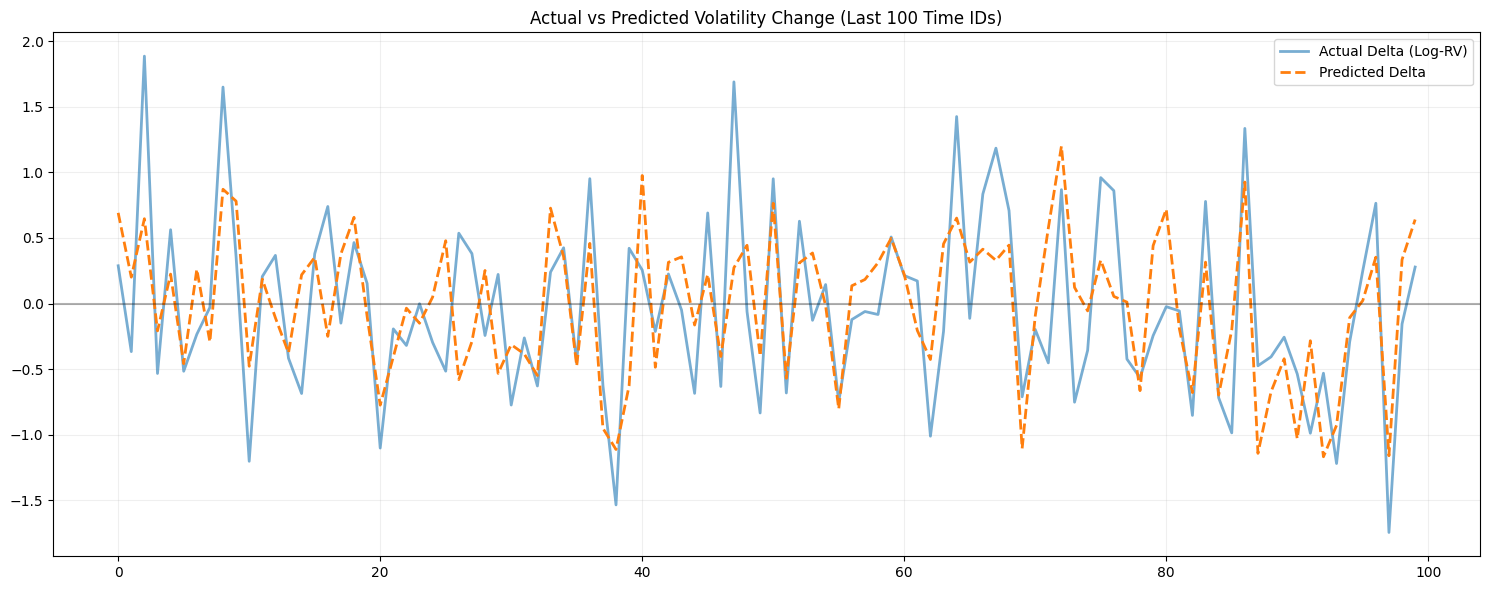

In [4]:
# ================================================================================
# VOLATILITY FORECAST PIPELINE — COMPLETE, LEAKAGE-FREE + HYPERPARAMETER TUNING
# ================================================================================

import numpy as np
import pandas as pd
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt
import optuna

from scipy.optimize import minimize
from scipy.stats import spearmanr, pearsonr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, RobustScaler
from numpy.linalg import lstsq

import tensorflow as tf
from tensorflow.keras import models, optimizers
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling1D, Concatenate,
)
from tensorflow.keras.callbacks import EarlyStopping

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Constants ─────────────────────────────────────────────────────────────────
BUCKET_SIZE  = 60
N_BUCKETS    = 10
N_FACTORS    = 5
LAG_DAILY    = 5
LAG_WEEKLY   = 10
LAG_MONTHLY  = 20
N_CLUSTERS   = 7 # For Market Grouping

tf.random.set_seed(42)
np.random.seed(42)


# ================================================================================
# HELPERS (Data Prep & Feature Engineering)
# ================================================================================


def compute_log_rv_matrix(df_raw):
    stock_cols = [c for c in df_raw.columns
                  if c not in ['time_id', 'seconds_in_bucket',
                                'bucket_group', 'time_id_orig']]

    def get_rv(group):
        log_prices = np.log(group[stock_cols].replace(0, np.nan)).ffill()
        log_ret    = log_prices.diff().dropna()
        rv         = np.sqrt((log_ret ** 2).sum() / len(log_ret))  # ← per-tick
        return np.log(rv + 1e-11)

    full_rv = df_raw.groupby('time_id')[stock_cols].apply(get_rv)
    return full_rv, stock_cols


MAX_TICKS = 50  # tune to match your typical raw tick count per session

def reshape_for_cnn(df_raw, stock_cols, max_ticks=MAX_TICKS):
    time_ids = df_raw['time_id'].unique()
    n_stocks = len(stock_cols)
    seqs = []

    for tid in time_ids:
        group = df_raw[df_raw['time_id'] == tid].sort_values('seconds_in_bucket')
        logp  = np.log(group[stock_cols].replace(0, np.nan)).ffill()
        dlog  = logp.diff().fillna(0).values        # (ticks, n_stocks)

        if len(dlog) >= max_ticks:
            seq = dlog[-max_ticks:]                 # keep most recent ticks
        else:
            pad = np.zeros((max_ticks - len(dlog), n_stocks))
            seq = np.vstack([pad, dlog])

        seqs.append(seq)

    X_seq = np.nan_to_num(np.stack(seqs))           # (n_time, max_ticks, n_stocks)
    return X_seq, time_ids


def asymmetric_huber(delta=0.5, neg_weight=5.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        err = y_true - y_pred
        abs_err = tf.abs(err)
        huber = tf.where(abs_err <= delta, 0.5 * tf.square(err), delta * (abs_err - 0.5 * delta))
        w = tf.where(y_true < -1.0, neg_weight, 1.0)
        return tf.reduce_mean(w * huber)
    return loss


def get_target_bucket_features(df_raw, target_stock):
    records = []
    for tid, group in df_raw.groupby('time_id'):
        group   = group.sort_values('seconds_in_bucket')   # ← add this
        prices  = group[target_stock].replace(0, np.nan).ffill().values
        seconds = group['seconds_in_bucket'].values
        if len(prices) < 2:
            continue

        log_ret = np.diff(np.log(prices))

        # Time-based late volatility windows (preserves economic meaning)
        late_5_mask = seconds[1:] >= (seconds[-1] - 300)   # last 300s
        late_3_mask = seconds[1:] >= (seconds[-1] - 180)   # last 180s
        rv_late_5 = np.log(np.sqrt(np.sum(log_ret[late_5_mask]**2)) + 1e-11)
        rv_late_3 = np.log(np.sqrt(np.sum(log_ret[late_3_mask]**2)) + 1e-11)

        # Directional stats via lstsq — unchanged
        bucket_vols = np.abs(log_ret)
        if len(bucket_vols) > 2:
            mat = np.vstack([np.ones(len(bucket_vols)),
                             np.arange(len(bucket_vols))]).T
            coefs, err, _, _ = lstsq(mat, bucket_vols, rcond=None)
            err_val   = err[0] if err.size > 0 else 0.0
            mean_val  = coefs[0] + (len(bucket_vols) / 2) * coefs[1]
            slope_val = coefs[1]
        else:
            mean_val, slope_val, err_val = np.nan, np.nan, np.nan

        records.append({
            'time_id': tid,
            'target_rv_late5': rv_late_5,
            'target_rv_late3': rv_late_3,
            'dir_mean': mean_val,
            'dir_slope': slope_val,
            'dir_err': err_val
        })

    return pd.DataFrame(records).set_index('time_id')


def get_mean_reversion_features(df_features):
    m_df = pd.DataFrame(index=df_features.index)
    rolling_max           = df_features['target_rv'].rolling(window=10).max()
    m_df['dist_to_peak']  = df_features['target_rv'] - rolling_max
    m_df['rv_momentum']   = df_features['target_rv'].diff()
    rolling_std           = df_features['target_rv'].rolling(20).std().fillna(1.0)
    m_df['z_score_proxy'] = (df_features['target_rv'] - df_features['lag_daily']) / (rolling_std + 1e-6)
    return m_df


def get_static_features(full_rv, bucket_feats, train_time_ids):
    """
    Computes rolling features across the ENTIRE continuous timeline (no test gaps),
    but mathematically restricts PCA, KNN, and KMeans fitting ONLY to train_time_ids.
    """
    rv_matrix    = full_rv.replace([np.inf, -np.inf], np.nan).dropna()
    target_stock = full_rv.columns[0]
    features     = pd.DataFrame(index=rv_matrix.index)
    features['target_rv'] = rv_matrix[target_stock]

    # Isolate training matrix for zero-leakage fitting
    train_mask = rv_matrix.index.isin(train_time_ids)
    train_rv_matrix = rv_matrix[train_mask]

    # Cross-sectional
    features['mkt_mean_rv']   = rv_matrix.mean(axis=1)
    features['mkt_median_rv'] = rv_matrix.median(axis=1)
    features['rv_vs_mkt']     = features['target_rv'] - features['mkt_mean_rv']

    # ── 1. Market-Level Clustering (K-Means - Fit strictly on Train) ──────────
    kmeans = KMeans(n_clusters=min(N_CLUSTERS, len(train_rv_matrix.columns)), random_state=42, n_init=10)
    kmeans.fit(train_rv_matrix.T)

    # We apply the learned clusters to all time steps
    cluster_labels = kmeans.labels_
    cluster_features = {}
    for c in range(kmeans.n_clusters):
        c_stocks = rv_matrix.columns[cluster_labels == c]
        if len(c_stocks) > 0:
            cluster_features[f'cluster_{c}_mean_rv'] = rv_matrix[c_stocks].mean(axis=1)
        else:
            cluster_features[f'cluster_{c}_mean_rv'] = 0.0

    cluster_df = pd.DataFrame(cluster_features, index=rv_matrix.index)

    # ── 2. StandardScaler + PCA (Fit strictly on Train) ───────────────────────
    scaler      = StandardScaler()
    scaled_tr   = scaler.fit_transform(train_rv_matrix)
    scaled_all  = scaler.transform(rv_matrix)

    pca         = PCA(n_components=N_FACTORS)
    pca.fit(scaled_tr)
    mkt_factors = pca.transform(scaled_all)

    mkt_df = pd.DataFrame(
        mkt_factors, index=rv_matrix.index,
        columns=[f'mkt_f{i}' for i in range(N_FACTORS)]
    )

    # ── 3. KNN: Stock Similarity (Fit strictly on Train) ──────────────────────
    nn_stock = NearestNeighbors(
        n_neighbors=min(5, len(train_rv_matrix.columns)),
        metric='manhattan'
    ).fit(train_rv_matrix.T)

    _, s_idx = nn_stock.kneighbors(train_rv_matrix.T)
    similar_stocks_indices = s_idx[0, 1:]

    # ── 4. KNN: Time Similarity (Safe to map all, enforced causality below) ───
    nn_time = NearestNeighbors(n_neighbors=50, metric='manhattan').fit(mkt_factors)
    _, t_idx = nn_time.kneighbors(mkt_factors)

    # ── 5. Spatio-Temporal Feature ("Tau") ────────────────────────────────────
    spatio_temp_feat = []

    for row_idx in range(len(t_idx)):
        neighbors = t_idx[row_idx]
        # CAUSALITY: Keep only regimes that happened in the PAST
        past = [i for i in neighbors if i < row_idx]

        if not past:
            spatio_temp_feat.append(np.nan)
        else:
            val = rv_matrix.iloc[past[:5], similar_stocks_indices].values.mean()
            spatio_temp_feat.append(val)

    t_feats = pd.DataFrame(index=rv_matrix.index)
    t_feats['neighbor_spatio_tau'] = spatio_temp_feat

    # ── 6. Lags & Vol-of-Vol ──────────────────────────────────────────────────
    features['lag_1']             = features['target_rv'].shift(1)
    features['lag_daily']         = features['target_rv'].rolling(LAG_DAILY).mean()
    features['lag_weekly']        = features['target_rv'].rolling(LAG_WEEKLY).mean()
    features['lag_monthly']       = features['target_rv'].rolling(LAG_MONTHLY).mean()
    features['vol_of_vol_daily']  = features['target_rv'].rolling(LAG_DAILY).std()
    features['vol_of_vol_weekly'] = features['target_rv'].rolling(LAG_WEEKLY).std()

    # ── 7. Combine Everything ─────────────────────────────────────────────────
    reversion_df   = get_mean_reversion_features(features)

    # Merge existing + K-Means + lstsq Bucket Features
    final_features = features.join([mkt_df, t_feats, reversion_df, cluster_df, bucket_feats])

    final_features['neighbor_spatio_tau'] = final_features['neighbor_spatio_tau'].ffill()

    return final_features.dropna()


# ================================================================================
# MODEL BUILDERS
# ================================================================================

def build_cnn(seq_shape, static_shape, hp=None):
    hp = hp or dict(filters_1=32, filters_2=64, dense_units=64, dropout=0.2, lr=1e-3)

    seq_in = Input(shape=seq_shape, name='seq_input')
    x = Conv1D(hp['filters_1'], 3, padding='same', activation='swish')(seq_in)
    x = BatchNormalization()(x)
    x = Dropout(hp['dropout'])(x)
    x = Conv1D(hp['filters_2'], 3, padding='same', activation='swish')(x)
    x = GlobalAveragePooling1D()(x)

    static_in = Input(shape=static_shape, name='static_input')
    y = Dense(hp['dense_units'], activation='swish')(static_in)
    y = BatchNormalization()(y)

    z = Concatenate()([x, y])
    z = Dense(hp['dense_units'], activation='swish')(z)
    z = Dropout(hp['dropout'])(z)
    out = Dense(1, activation='linear')(z)

    model = models.Model([seq_in, static_in], out)
    model.compile(optimizer=optimizers.Adam(hp['lr']),
                  loss=asymmetric_huber(), metrics=['mae'])
    return model


def build_mlp(input_shape, hp=None):
    hp = hp or dict(units_1=128, units_2=64, dropout=0.2, lr=1e-3)

    inp = Input(shape=input_shape)
    x   = Dense(hp['units_1'], activation='swish')(inp)
    x   = BatchNormalization()(x)
    x   = Dropout(hp['dropout'])(x)
    x   = Dense(hp['units_2'], activation='swish')(x)
    out = Dense(1, activation='linear')(x)

    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(hp['lr']),
                  loss=asymmetric_huber(), metrics=['mae'])
    return model


# ================================================================================
# METRICS & TUNING (Kept Intact)
# ================================================================================

def evaluate_forecast(y_true, y_pred, label='Blend'):
    eps = 1e-8
    err = y_true - y_pred

    mae   = np.mean(np.abs(err))
    rmse  = np.sqrt(np.mean(err**2))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs(err) / (np.abs(y_true) + eps)) * 100
    smape = np.mean(2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

    rv_true = np.clip(y_true, eps, None)
    rv_pred = np.clip(y_pred, eps, None)
    qlike   = np.mean(rv_true / rv_pred - np.log(rv_true / rv_pred) - 1)

    naive_err = y_true[1:] - y_true[:-1]
    theils_u2 = (np.sqrt(np.mean(err[1:]**2)) /
                 (np.sqrt(np.mean(naive_err**2)) + eps))

    X_mz               = sm.add_constant(y_pred)
    mz                 = sm.OLS(y_true, X_mz).fit()
    mz_r2              = mz.rsquared
    mz_intercept, mz_slope = mz.params

    hit_rate     = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    correct_mask = np.sign(y_true) == np.sign(y_pred)
    dir_r2       = (r2_score(y_true[correct_mask], y_pred[correct_mask])
                    if correct_mask.sum() > 1 else np.nan)

    thresh_90, thresh_95 = np.quantile(np.abs(y_true), [0.90, 0.95])
    tail_mae_90 = np.mean(np.abs(err[np.abs(y_true) >= thresh_90]))
    tail_mae_95 = np.mean(np.abs(err[np.abs(y_true) >= thresh_95]))

    spearman_r, _ = spearmanr(y_true, y_pred)
    pearson_r,  _ = pearsonr(y_true,  y_pred)
    bias          = np.mean(err)
    bias_pct      = bias / (np.mean(np.abs(y_true)) + eps) * 100

    metrics = {
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE (%)': mape, 'SMAPE (%)': smape, 'QLIKE': qlike,
        "Theil's U2": theils_u2, 'MZ R²': mz_r2,
        'MZ Intercept': mz_intercept, 'MZ Slope': mz_slope,
        'Hit Rate (%)': hit_rate, 'Dir R²': dir_r2,
        'Tail MAE 90': tail_mae_90, 'Tail MAE 95': tail_mae_95,
        'Spearman r': spearman_r, 'Pearson r': pearson_r,
        'Bias': bias, 'Bias (%)': bias_pct,
    }

    col_w = 18
    print(f"\n{'='*42}\n  Forecast Metrics — {label}\n{'='*42}")
    print(f"  {'Metric':<{col_w}}  Value\n  {'-'*38}")
    for k, v in metrics.items():
        print(f"  {k:<{col_w}}  {v:+.4f}")
    print(f"{'='*42}\n")
    return metrics


def learn_blend_weights(oof_preds, y_val):
    names = list(oof_preds.keys())
    P     = np.column_stack([oof_preds[n] for n in names])
    n     = len(names)

    result = minimize(
        fun=lambda w: np.mean((y_val - P @ w) ** 2),
        x0=np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
    )
    weights = result.x
    print("\nLearned blend weights (on validation slice):")
    for name, w in zip(names, weights):
        print(f"  {name:<10}: {w:.4f}")
    return dict(zip(names, weights))


def tune_cnn(X_seq_fit, X_stat_fit, y_fit,
             X_seq_val, X_stat_val, y_val,
             seq_shape, static_shape, n_trials=30):

    def objective(trial):
        hp = dict(
            filters_1   = trial.suggest_categorical('filters_1',   [16, 32, 64]),
            filters_2   = trial.suggest_categorical('filters_2',   [32, 64, 128]),
            dense_units = trial.suggest_categorical('dense_units', [32, 64, 128]),
            dropout     = trial.suggest_float('dropout', 0.1, 0.5, step=0.05),
            lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            batch_size  = trial.suggest_categorical('batch_size',  [16, 32, 64]),
        )
        tf.keras.backend.clear_session()
        m  = build_cnn(seq_shape, static_shape, hp)
        es = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=0)
        h  = m.fit([X_seq_fit, X_stat_fit], y_fit,
                   validation_data=([X_seq_val, X_stat_val], y_val),
                   epochs=50, batch_size=hp['batch_size'],
                   callbacks=[es], verbose=0)
        return min(h.history['val_loss'])

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"\n[CNN]  best val_loss={study.best_value:.6f}  params={study.best_params}")
    return study.best_params


def tune_mlp(X_stat_fit, y_fit, X_stat_val, y_val, static_shape, n_trials=30):

    def objective(trial):
        hp = dict(
            units_1    = trial.suggest_categorical('units_1',    [64, 128, 256]),
            units_2    = trial.suggest_categorical('units_2',    [32, 64, 128]),
            dropout    = trial.suggest_float('dropout', 0.1, 0.5, step=0.05),
            lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64]),
        )
        tf.keras.backend.clear_session()
        m  = build_mlp(static_shape, hp)
        es = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=0)
        h  = m.fit(X_stat_fit, y_fit,
                   validation_data=(X_stat_val, y_val),
                   epochs=50, batch_size=hp['batch_size'],
                   callbacks=[es], verbose=0)
        return min(h.history['val_loss'])

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"\n[MLP]  best val_loss={study.best_value:.6f}  params={study.best_params}")
    return study.best_params


def tune_lgbm(X_stat_fit, y_fit, X_stat_val, y_val, n_trials=50):

    def objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int('n_estimators', 100, 1000, step=100),
            learning_rate     = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            num_leaves        = trial.suggest_int('num_leaves', 15, 127),
            max_depth         = trial.suggest_int('max_depth', 3, 12),
            min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
            subsample         = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            n_jobs=-1, verbose=-1,
        )
        m = lgb.LGBMRegressor(**params)
        m.fit(X_stat_fit, y_fit,
              eval_set=[(X_stat_val, y_val)],
              callbacks=[lgb.early_stopping(20, verbose=False),
                         lgb.log_evaluation(-1)])
        return np.mean((y_val - m.predict(X_stat_val)) ** 2)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"\n[LGBM] best val_MSE={study.best_value:.6f}  params={study.best_params}")
    return study.best_params


# ================================================================================
# MASTER PIPELINE
# ================================================================================

def run_blend_pipeline(df, cnn_trials=30, mlp_trials=30, lgbm_trials=50):

    print("--- Phase 1: Data Prep ---")

    # Sort raw data — no downsampling, no bucket filter
    time_order = df['time_id'].unique()
    time_rank  = {tid: i for i, tid in enumerate(time_order)}
    df_raw = (df.assign(time_rank=df['time_id'].map(time_rank))
                .sort_values(['time_rank', 'seconds_in_bucket'])
                .drop(columns='time_rank')
                .reset_index(drop=True))

    full_rv, stock_cols = compute_log_rv_matrix(df_raw)

    target_stock = stock_cols[0]
    bucket_feats = get_target_bucket_features(df_raw, target_stock)  # raw df

    X_seq_all, time_ids = reshape_for_cnn(df_raw, stock_cols)

    seq_map = pd.DataFrame({'time_id': time_ids})
    seq_map['seq_obj'] = list(X_seq_all)
    seq_map = seq_map.set_index('time_id')

    # Pre-calculate training boundary to guarantee zero data leakage
    valid_feature_times = time_ids[LAG_MONTHLY:-1]
    split_idx      = int(len(valid_feature_times) * 0.8)
    train_time_ids = valid_feature_times[:split_idx]

    print("--- Phase 2: Feature Engineering (No Leaks, with KMeans & lstsq) ---")
    # NEW: Passing bucket_feats into static calculation
    static_df = get_static_features(full_rv, bucket_feats, train_time_ids)

    # Align Sequences and Static Features
    common = static_df.index.intersection(seq_map.index)
    static_df = static_df.loc[common]
    seq_map = seq_map.loc[common]

    X_seq = np.stack(seq_map['seq_obj'].values)
    X_static = static_df.drop(columns=['target_rv']).values

    # Target: RV(t+1) - RV(t)
    y_raw = (static_df['target_rv'].shift(-1) - static_df['target_rv']).values

    # Drop last row (NaN target)
    X_seq = X_seq[:-1]; X_static = X_static[:-1]; y_raw = y_raw[:-1]
    time_ids_aligned = common[:-1]

    # Split using explicit time boundary mask
    train_mask = time_ids_aligned.isin(train_time_ids)
    test_mask  = ~train_mask

    X_seq_tr, X_seq_te       = X_seq[train_mask], X_seq[test_mask]
    X_stat_tr_raw, X_stat_te = X_static[train_mask], X_static[test_mask]
    y_tr_raw, y_te_raw       = y_raw[train_mask], y_raw[test_mask]

    # Scale strictly on train
    feat_scaler = StandardScaler()
    X_stat_tr   = feat_scaler.fit_transform(X_stat_tr_raw)
    X_stat_te   = feat_scaler.transform(X_stat_te)

    y_scaler = RobustScaler()
    y_tr     = y_scaler.fit_transform(y_tr_raw.reshape(-1, 1)).ravel()
    y_te     = y_scaler.transform(y_te_raw.reshape(-1, 1)).ravel()

    # Split Train into Fit (90%) and Val (10%) for tuning & early stopping
    val_split  = int(len(y_tr) * 0.9)
    X_seq_fit,  X_seq_val  = X_seq_tr[:val_split],  X_seq_tr[val_split:]
    X_stat_fit, X_stat_val = X_stat_tr[:val_split], X_stat_tr[val_split:]
    y_fit,      y_val      = y_tr[:val_split],      y_tr[val_split:]

    seq_shape    = X_seq_fit.shape[1:]
    static_shape = (X_stat_fit.shape[1],)

    print(f"Fit Set:  Seq={X_seq_fit.shape}, Static={X_stat_fit.shape}")
    print(f"Val Set:  Seq={X_seq_val.shape}, Static={X_stat_val.shape}")
    print(f"Test Set: Seq={X_seq_te.shape},  Static={X_stat_te.shape}")

    print("--- Phase 3: Hyperparameter Tuning ---")

    cnn_hp = tune_cnn(
        X_seq_fit, X_stat_fit, y_fit, X_seq_val, X_stat_val, y_val,
        seq_shape, static_shape, n_trials=cnn_trials,
    ) if cnn_trials > 0 else {}

    mlp_hp = tune_mlp(
        X_stat_fit, y_fit, X_stat_val, y_val,
        static_shape, n_trials=mlp_trials,
    ) if mlp_trials > 0 else {}

    lgbm_hp = tune_lgbm(
        X_stat_fit, y_fit, X_stat_val, y_val,
        n_trials=lgbm_trials,
    ) if lgbm_trials > 0 else {}

    print("--- Phase 4: Final Training ---")

    es = EarlyStopping(monitor='val_loss', patience=5,
                       restore_best_weights=True, verbose=0)

    print("1. Training CNN...")
    tf.keras.backend.clear_session()
    cnn = build_cnn(seq_shape, static_shape, cnn_hp or None)
    cnn.fit(
        [X_seq_fit, X_stat_fit], y_fit,
        validation_data=([X_seq_val, X_stat_val], y_val),
        epochs=100, batch_size=cnn_hp.get('batch_size', 32),
        callbacks=[es], verbose=0,
    )

    print("2. Training MLP...")
    tf.keras.backend.clear_session()
    mlp = build_mlp(static_shape, mlp_hp or None)
    mlp.fit(
        X_stat_fit, y_fit,
        validation_data=(X_stat_val, y_val),
        epochs=100, batch_size=mlp_hp.get('batch_size', 32),
        callbacks=[es], verbose=0,
    )

    print("3. Training LightGBM...")
    final_lgbm_hp = {k: v for k, v in lgbm_hp.items() if k != 'n_estimators'}
    lgbm = lgb.LGBMRegressor(n_estimators=2000, n_jobs=-1, verbose=-1, **final_lgbm_hp)
    lgbm.fit(
        X_stat_fit, y_fit,
        eval_set=[(X_stat_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )

    print("4. Learning blend weights...")
    weights = learn_blend_weights({
        'cnn':  cnn.predict([X_seq_val, X_stat_val], verbose=0).ravel(),
        'mlp':  mlp.predict(X_stat_val, verbose=0).ravel(),
        'lgbm': lgbm.predict(X_stat_val),
    }, y_val)

    print("--- Phase 5: Test Evaluation ---")

    p_blend = (
        weights['cnn']  * cnn.predict([X_seq_te, X_stat_te], verbose=0).ravel() +
        weights['mlp']  * mlp.predict(X_stat_te, verbose=0).ravel() +
        weights['lgbm'] * lgbm.predict(X_stat_te)
    )

    final_preds = y_scaler.inverse_transform(p_blend.reshape(-1, 1)).ravel()
    y_true      = y_scaler.inverse_transform(y_te.reshape(-1, 1)).ravel()

    evaluate_forecast(y_true, final_preds, label='CNN+MLP+LGBM Blend (Tuned & Un-Leaked)')
    return y_true, final_preds


# ================================================================================
# VISUALISATION
# ================================================================================

def plot_predictions(y_true, y_pred, n_samples=100):
    plt.figure(figsize=(15, 6))
    plt.plot(y_true[-n_samples:], label='Actual Delta (Log-RV)',
             color='#1f77b4', alpha=0.6, lw=2)
    plt.plot(y_pred[-n_samples:], label='Predicted Delta',
             color='#ff7f0e', linestyle='--', lw=2)
    plt.axhline(0, color='black', alpha=0.3)
    plt.title(f'Actual vs Predicted Volatility Change (Last {n_samples} Time IDs)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


# ================================================================================
# MAIN
# ================================================================================

if __name__ == "__main__":
    df = pd.read_csv("/content/drive/MyDrive/final.csv")
    y_out, preds_out = run_blend_pipeline(
        df,
        cnn_trials=30,
        mlp_trials=30,
        lgbm_trials=50,
    )
    plot_predictions(y_out, preds_out)